# YOLO phase2 v2 (주제 : YOLO 내장 증강 도입)

# 1. 환경 설정 및 데이터 확인


## 1-1. 기본 경로 설정

In [ ]:
import os
import sys
import json
import time
import random
import datetime as dt
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage, ImageDraw, ImageFont

import math
import torch
from torchvision.ops import nms

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

KOR_DATA_TOKEN = '\ucd08\uae09_\ud504\ub85c\uc81d\ud2b8'
PROJECT_ROOT = Path('/content/drive/MyDrive/pill_detection_project') if IN_COLAB else Path.cwd()
DATA_DIR = Path('/content/drive/MyDrive/data') / KOR_DATA_TOKEN / 'dataset' if IN_COLAB else PROJECT_ROOT / 'data'

RUNS_DIR = PROJECT_ROOT / 'models' / 'yolo' / 'runs'
MODELS_DIR = PROJECT_ROOT / 'models' / 'yolo'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'yolo'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

TEST_IMAGE_DIR = Path('/content/drive/MyDrive/data') / KOR_DATA_TOKEN / 'dataset' / 'final_test_images'
TRAIN_JSON = DATA_DIR / 'merged_annotations_train_final.json'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:', DATA_DIR)
print('TEST_IMAGE_DIR:', TEST_IMAGE_DIR)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/pill_detection_project
DATA_DIR: /content/drive/MyDrive/data/초급_프로젝트/dataset
TEST_IMAGE_DIR: /content/drive/MyDrive/data/초급_프로젝트/dataset/final_test_images


## 1-2. 상세 경로 설정 및 고정 파라미터 설정

In [ ]:
# NO CP (증강 미적용) 산출물 경로
NO_CP = {
    'data_yaml': DATA_DIR / 'data_aug_v1.yaml',
    'train_json': DATA_DIR / 'train_letterbox_aug_v1.json',
    'val_json': DATA_DIR / 'val_letterbox_aug_v1.json',
    "train_img": Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images_aug_v1/train"),
    "train_lbl": Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images_aug_v1/train"),  # 같은 폴더
    "val_img":   Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images_aug_v1/val"),
    "val_lbl":   Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images_aug_v1/val"),    # 같은 폴더
}

# CP(팀 증강) 산출물 경로: 공유드라이브 경로로 직접 수정
CP_ROOT = Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/new_aug")

CP = {
    "train_img":  CP_ROOT / "letterbox_images" / "train",
    "train_lbl":  CP_ROOT / "letterbox_images" / "train",
    "train_json": CP_ROOT / "train_letterbox.json",
    "val_img":    CP_ROOT / "letterbox_images" / "val",
    "val_lbl":    CP_ROOT / "letterbox_images" / "val",
    "val_json":   CP_ROOT / "val_letterbox.json",
}

# LR 튜닝 대상(고정)
MODEL_SPECS = [
    {'model_name': 'yolov8s_aug_v1', 'weights': 'yolov8s.pt'},
    {'model_name': 'yolo11m_aug_v1', 'weights': 'yolo11m.pt'},
]

# 고정값
EPOCHS = 30
PATIENCE = 10
BATCH = 16
IMGSZ = 800
OPTIMIZER = 'SGD'
YOLO_PLOTS = False  # True면 YOLO plot 저장, Colab PIL 오류 시 False

# 공통평가 파라미터
PREDICT_CONF_FOR_EVAL = 0.001
NMS_IOU = 0.7
CONF_THRESHOLD = 0.001
PR_IOU_THRESHOLD = 0.5

# 학습 관련
# RUN_LR_TUNING = False
# SMOKE_MODE = False


## 1-3. 데이터 존재/개수 체크

In [3]:
# no CP 데이    이미지 / 라벨 개수 및 불일치 점검
for split in ["train", "val"]:
    d = Path(f"/content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images_aug_v1/{split}")
    imgs = [p for p in d.glob("*") if p.suffix.lower() in [".jpg",".jpeg",".png",".bmp",".webp"]]
    lbls = list(d.glob("*.txt"))
    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}
    print(split, "img:", len(imgs), "lbl:", len(lbls), "img-only:", len(img_stems-lbl_stems), "lbl-only:", len(lbl_stems-img_stems))

train img: 1350 lbl: 1350 img-only: 0 lbl-only: 0
val img: 139 lbl: 139 img-only: 0 lbl-only: 0


In [7]:
# CP 데이터셋 이미지/라벨 개수 및 불일치 점검
for split in ["train", "val"]:
    d = Path(f"/content/drive/MyDrive/data/초급_프로젝트/dataset/new_aug/letterbox_images/{split}")
    imgs = [p for p in d.glob("*") if p.suffix.lower() in [".jpg",".jpeg",".png",".bmp",".webp"]]
    lbls = list(d.glob("*.txt"))
    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}
    print(split, "img:", len(imgs), "lbl:", len(lbls), "img-only:", len(img_stems-lbl_stems), "lbl-only:", len(lbl_stems-img_stems))

train img: 1776 lbl: 1776 img-only: 0 lbl-only: 0
val img: 149 lbl: 149 img-only: 0 lbl-only: 0


# 2. 학습/평가 함수 정의


In [7]:
# 충돌 이슈로 강제 설치
%pip install -q numpy==2.0.2 scipy==1.16.3 ultralytics==8.4.24

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.9 MB/s eta 0:00:00


In [10]:
#@title 공통평가 함수 정의
from ultralytics import YOLO
import importlib.util
import json
from pathlib import Path
from datetime import datetime

EVAL_FILE = PROJECT_ROOT / "src" / "evaluation" / "evaluation.py"
if not EVAL_FILE.exists():
    raise FileNotFoundError(f"evaluation.py not found: {EVAL_FILE}")

spec = importlib.util.spec_from_file_location("eval_mod", str(EVAL_FILE))
eval_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(eval_mod)
convert_yolo_results = eval_mod.convert_yolo_results
evaluate_all = eval_mod.evaluate_all


def run_common_eval_on_split(
    model_name,
    weights_name,
    ckpt_path,
    gt_json_path,
    image_dir,
    split_tag="val",
    train_loss=None,
    val_loss=None,
):
    # 1) YOLO cls -> 원본 category_id 매핑
    with open(TRAIN_JSON, "r", encoding="utf-8") as f:
        train_coco = json.load(f)
    train_category_ids = sorted({int(a["category_id"]) for a in train_coco["annotations"]})
    yolo2cat = {i: cid for i, cid in enumerate(train_category_ids)}

    # 2) GT image_id 매핑
    with open(gt_json_path, "r", encoding="utf-8") as f:
        gt_coco = json.load(f)
    filename_to_image_id = {Path(img["file_name"]).name: int(img["id"]) for img in gt_coco["images"]}

    # 3) 예측
    model = YOLO(str(ckpt_path))
    pred_results = model.predict(
        source=str(image_dir),
        imgsz=IMGSZ,
        conf=PREDICT_CONF_FOR_EVAL,
        iou=NMS_IOU,
        save=False,
        verbose=False,
    )

    valid_results, image_ids = [], []
    for r in pred_results:
        fname = Path(r.path).name
        if fname in filename_to_image_id:
            valid_results.append(r)
            image_ids.append(filename_to_image_id[fname])

    yolo_predictions = convert_yolo_results(valid_results, image_ids=image_ids)

    # 4) category_id remap
    mapped_predictions = []
    for pred in yolo_predictions:
        cls_idx = int(pred["category_id"])
        if cls_idx not in yolo2cat:
            continue
        item = dict(pred)
        item["category_id"] = int(yolo2cat[cls_idx])
        mapped_predictions.append(item)

    # 5) 공통 평가
    if len(mapped_predictions) == 0:
        metrics = {
            "mAP@50": 0.0,
            "mAP@75:95": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "details": {
                "tp": 0,
                "fp": 0,
                "fn": int(len(gt_coco.get("annotations", []))),
            },
        }
    else:
        metrics = evaluate_all(
            gt_json_path=str(gt_json_path),
            predictions=mapped_predictions,
            conf_threshold=CONF_THRESHOLD,
            pr_iou_threshold=PR_IOU_THRESHOLD,
            temp_json_path=str(RESULTS_DIR / f"temp_eval_{model_name}_{split_tag}.json"),
        )

    rec = {
        "timestamp": datetime.now().isoformat(),
        "model_name": model_name,
        "weights": weights_name,
        "split": split_tag,
        "epochs": EPOCHS,
        "imgsz": IMGSZ,
        "batch": BATCH,
        "best_weights_path": str(ckpt_path),
        "num_predictions": len(mapped_predictions),
        "train_loss": train_loss,
        "val_loss": val_loss,
        **metrics,
    }
    return rec

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 3. YOLO 내장 증강 적용 학습

In [ ]:
#@title Final Tuning (YOLO built-in aug ON)
NO_CP_DATA_YAML = "/content/drive/MyDrive/data/초급_프로젝트/dataset/data_aug_v1.yaml"
CP_DATA_YAML    = "/content/drive/MyDrive/data/초급_프로젝트/dataset/data.yaml"

EXPERIMENTS = [
    {
        "run_name": "yolov8s_no_cp_augon_final",
        "ckpt": "/content/drive/MyDrive/pill_detection_project/models/yolo/runs/yolov8s_no_cp_ft_ext10/weights/best.pt",
        "data": NO_CP_DATA_YAML,
        "lr0": 0.003,
    },
    {
        "run_name": "yolo11m_cp_augon_final",
        "ckpt": "/content/drive/MyDrive/pill_detection_project/models/yolo/runs/yolo11m_cp_ft_uf/weights/best.pt",
        "data": CP_DATA_YAML,
        "lr0": 0.002,
    },
]

# 내장 증강 ON (반전/블러/erasing 사용 안함)
AUG = dict(
    augment=True,
    fliplr=0.0, flipud=0.0,
    degrees=5.0, translate=0.05, scale=0.15, shear=0.0, perspective=0.0,
    hsv_h=0.015, hsv_s=0.20, hsv_v=0.20,
    mosaic=0.20, mixup=0.0, copy_paste=0.0,
    erasing=0.0,
)

rows = []

for exp in EXPERIMENTS:
    run_name = exp["run_name"]
    ckpt = Path(exp["ckpt"])
    data_yaml = Path(exp["data"])

    if not ckpt.exists():
        raise FileNotFoundError(f"ckpt not found: {ckpt}")
    if not data_yaml.exists():
        raise FileNotFoundError(f"data yaml not found: {data_yaml}")

    print("\n" + "=" * 80)
    print(f"Run: {run_name}")
    print(f"ckpt: {ckpt}")
    print(f"data: {data_yaml}")

    model = YOLO(str(ckpt))

    t0 = time.time()
    model.train(
        data=str(data_yaml),
        epochs=EPOCHS,
        patience=PATIENCE,
        imgsz=IMGSZ,
        batch=BATCH,
        optimizer="SGD",
        lr0=exp["lr0"],
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        plots=False,          # PIL thread 에러 방지
        verbose=True,
        **AUG
    )
    runtime_min = (time.time() - t0) / 60.0

    hist_csv = RUNS_DIR / run_name / "results.csv"
    best_pt = RUNS_DIR / run_name / "weights" / "best.pt"

    rec = {
        "run": run_name,
        "best_pt": str(best_pt),
        "runtime_min": runtime_min,
        "lr0": exp["lr0"],
    }

    if hist_csv.exists():
        h = pd.read_csv(hist_csv)
        if len(h):
            rec["mAP50"] = float(h["metrics/mAP50(B)"].iloc[-1]) if "metrics/mAP50(B)" in h.columns else None
            rec["mAP50_95"] = float(h["metrics/mAP50-95(B)"].iloc[-1]) if "metrics/mAP50-95(B)" in h.columns else None
            rec["precision"] = float(h["metrics/precision(B)"].iloc[-1]) if "metrics/precision(B)" in h.columns else None
            rec["recall"] = float(h["metrics/recall(B)"].iloc[-1]) if "metrics/recall(B)" in h.columns else None

    rows.append(rec)

FINAL_AUGON_DF = pd.DataFrame(rows).sort_values("mAP50_95", ascending=False, na_position="last")
display(FINAL_AUGON_DF)
FINAL_AUGON_DF.to_csv(RESULTS_DIR / "final_augon_train_summary.csv", index=False)
print("saved:", RESULTS_DIR / "final_augon_train_summary.csv")



Run: yolov8s_no_cp_augon_final
ckpt: /content/drive/MyDrive/pill_detection_project/models/yolo/runs/yolov8s_no_cp_ft_ext10/weights/best.pt
data: /content/drive/MyDrive/data/초급_프로젝트/dataset/data_aug_v1.yaml
New https://pypi.org/project/ultralytics/8.4.27 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/data_aug_v1.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0

,run,best_pt,runtime_min,lr0,mAP50,mAP50_95,precision,recall
0,yolov8s_no_cp_augon_final,/content/drive/MyDrive/pill_detection_project/...,6.048799,0.003,0.88653,0.88363,0.80173,0.94190
1,yolo11m_cp_augon_final,/content/drive/MyDrive/pill_detection_project/...,10.471999,0.002,0.87549,0.87248,0.79141,0.91807


saved: /content/drive/MyDrive/pill_detection_project/results/yolo/final_augon_train_summary.csv


# 4. 평가

- Val 평가

In [14]:
#@title Common VAL 평가 (0.001 / 0.25 동시 비교)
import numpy as np
import pandas as pd
from pathlib import Path

# 평가할 run 직접 지정
EVAL_RUNS = [
    "yolov8s_no_cp_augon_final",
    "yolo11m_cp_augon_final",
]
VAL_JSON = Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/val_letterbox_aug_v1.json")
VAL_IMAGE_DIR = Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images_aug_v1/val")

GT_JSON = VAL_JSON
IMG_DIR = VAL_IMAGE_DIR

SPLIT_TAG = "val"

rows = []

for run_name in EVAL_RUNS:
    ckpt = RUNS_DIR / run_name / "weights" / "best.pt"
    if not ckpt.exists():
        print("[SKIP] ckpt not found:", ckpt)
        continue

    # conf=0.001
    PREDICT_CONF_FOR_EVAL = 0.001
    CONF_THRESHOLD = 0.001
    rec_001 = run_common_eval_on_split(
        model_name=run_name,
        weights_name="best.pt",
        ckpt_path=ckpt,
        gt_json_path=GT_JSON,
        image_dir=IMG_DIR,
        split_tag=SPLIT_TAG,
    )

    # conf=0.25
    PREDICT_CONF_FOR_EVAL = 0.25
    CONF_THRESHOLD = 0.25
    rec_025 = run_common_eval_on_split(
        model_name=run_name,
        weights_name="best.pt",
        ckpt_path=ckpt,
        gt_json_path=GT_JSON,
        image_dir=IMG_DIR,
        split_tag=SPLIT_TAG,
    )

    rows.append({
        "run": run_name,
        "mAP50_95@0.001": rec_001.get("mAP@75:95", np.nan),
        "mAP50@0.001": rec_001.get("mAP@50", np.nan),
        "precision@0.001": rec_001.get("precision", np.nan),
        "recall@0.001": rec_001.get("recall", np.nan),
        "num_pred@0.001": rec_001.get("num_predictions", np.nan),

        "mAP50_95@0.25": rec_025.get("mAP@75:95", np.nan),
        "mAP50@0.25": rec_025.get("mAP@50", np.nan),
        "precision@0.25": rec_025.get("precision", np.nan),
        "recall@0.25": rec_025.get("recall", np.nan),
        "num_pred@0.25": rec_025.get("num_predictions", np.nan),
    })

VAL_DUAL_THRESH_DF = pd.DataFrame(rows).sort_values("mAP50_95@0.25", ascending=False).reset_index(drop=True)
display(VAL_DUAL_THRESH_DF)

out_csv = RESULTS_DIR / "val_common_dual_threshold_compare.csv"
VAL_DUAL_THRESH_DF.to_csv(out_csv, index=False)
print("saved:", out_csv)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.20s).
Accumulating evaluation results...
DONE (t=0.32s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.880
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.889
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.889
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.878
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.961
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.961
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

,run,mAP50_95@0.001,mAP50@0.001,precision@0.001,recall@0.001,num_pred@0.001,mAP50_95@0.25,mAP50@0.25,precision@0.25,recall@0.25,num_pred@0.25
0,yolov8s_no_cp_augon_final,0.870116,0.889369,0.504751,0.986079,842,0.865505,0.884757,0.807619,0.983759,525
1,yolo11m_cp_augon_final,0.874549,0.895182,0.507109,0.993039,844,0.861601,0.882139,0.807619,0.983759,525


saved: /content/drive/MyDrive/pill_detection_project/results/yolo/val_common_dual_threshold_compare.csv


- 클래스별 지표
- v8s, v11m 각각

In [15]:
#@title 클래스별 AP (v8s / NO_CP yaml)
DATA_YAML = "/content/drive/MyDrive/data/초급_프로젝트/dataset/data_aug_v1.yaml"
RUN_NAME = "yolov8s_no_cp_augon_final"

best_pt = Path(f"/content/drive/MyDrive/pill_detection_project/models/yolo/runs/{RUN_NAME}/weights/best.pt")
if not best_pt.exists():
    raise FileNotFoundError(best_pt)

model = YOLO(str(best_pt))
m = model.val(data=DATA_YAML, split="val", imgsz=800, batch=16, plots=False, verbose=False)

rows = []
for i, (a50, a9595) in enumerate(zip(m.box.ap50, m.box.ap)):
    rows.append({
        "run_name": RUN_NAME,
        "class_idx": i,
        "class_name": model.names[i],
        "AP50": float(a50),
        "AP50_95": float(a9595),
    })

df_cls_v8 = pd.DataFrame(rows)
display(df_cls_v8.head(20))
display(df_cls_v8[["AP50","AP50_95"]].mean().to_frame("mean").T)

Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,153,835 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 117.0±15.4 MB/s, size: 146.8 KB)
val: Scanning /content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images_aug_v1/val.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 44.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 6.8it/s 1.3s
                   all        139        431      0.787      0.966      0.902      0.893
Speed: 1.1ms preprocess, 3.0ms inference, 0.0ms loss, 0.9ms postprocess per image


,run_name,class_idx,class_name,AP50,AP50_95
0,yolov8s_no_cp_augon_final,0,보령부스파정 5mg,0.891864,0.888445
1,yolov8s_no_cp_augon_final,1,뮤테란캡슐 100mg,0.771136,0.748142
2,yolov8s_no_cp_augon_final,2,일양하이트린정 2mg,0.905989,0.905989
3,yolov8s_no_cp_augon_final,3,기넥신에프정(은행엽엑스)(수출용),0.843327,0.839750
4,yolov8s_no_cp_augon_final,4,무코스타정(레바미피드)(비매품),0.925000,0.925000
5,yolov8s_no_cp_augon_final,5,알드린정,0.932778,0.932778
6,yolov8s_no_cp_augon_final,6,뉴로메드정(옥시라세탐),0.746250,0.717080
7,yolov8s_no_cp_augon_final,7,타이레놀정500mg,0.995000,0.995000
8,yolov8s_no_cp_augon_final,8,에어탈정(아세클로페낙),0.696429,0.696429
9,yolov8s_no_cp_augon_final,9,삼남건조수산화알루미늄겔정,0.862460,0.862460


,AP50,AP50_95
mean,0.902349,0.893256


In [19]:
#@title 클래스별 AP (11m / CP yaml)
DATA_YAML = "/content/drive/MyDrive/data/초급_프로젝트/dataset/new_aug/data.yaml"
RUN_NAME = "yolo11m_cp_augon_final"

best_pt = Path(f"/content/drive/MyDrive/pill_detection_project/models/yolo/runs/{RUN_NAME}/weights/best.pt")
if not best_pt.exists():
    raise FileNotFoundError(best_pt)

model = YOLO(str(best_pt))
m = model.val(data=DATA_YAML, split="val", imgsz=800, batch=16, plots=False, verbose=False)

rows = []
for i, (a50, a9595) in enumerate(zip(m.box.ap50, m.box.ap)):
    rows.append({
        "run_name": RUN_NAME,
        "class_idx": i,
        "class_name": model.names[i],
        "AP50": float(a50),
        "AP50_95": float(a9595),
    })

df_cls_11m = pd.DataFrame(rows)
display(df_cls_11m.head(20))
display(df_cls_11m[["AP50","AP50_95"]].mean().to_frame("mean").T)


Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO11m summary (fused): 126 layers, 20,086,315 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 139.7±6.3 MB/s, size: 147.5 KB)
val: Scanning /content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images/val.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 44.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 6.3it/s 1.4s
                   all        139        431      0.796      0.961      0.897      0.887
Speed: 1.2ms preprocess, 4.0ms inference, 0.0ms loss, 1.0ms postprocess per image


,run_name,class_idx,class_name,AP50,AP50_95
0,yolo11m_cp_augon_final,0,보령부스파정 5mg,0.869524,0.864108
1,yolo11m_cp_augon_final,1,뮤테란캡슐 100mg,0.757930,0.750386
2,yolo11m_cp_augon_final,2,일양하이트린정 2mg,0.918297,0.918297
3,yolo11m_cp_augon_final,3,기넥신에프정(은행엽엑스)(수출용),0.819703,0.819703
4,yolo11m_cp_augon_final,4,무코스타정(레바미피드)(비매품),0.937308,0.937308
5,yolo11m_cp_augon_final,5,알드린정,0.841746,0.841746
6,yolo11m_cp_augon_final,6,뉴로메드정(옥시라세탐),0.995000,0.995000
7,yolo11m_cp_augon_final,7,타이레놀정500mg,0.995000,0.995000
8,yolo11m_cp_augon_final,8,에어탈정(아세클로페낙),0.456250,0.456250
9,yolo11m_cp_augon_final,9,삼남건조수산화알루미늄겔정,0.884444,0.884444


,AP50,AP50_95
mean,0.896635,0.88654


# 5. CSV 생성

- 함수 정의

In [ ]:
#@title 함수 : 제출 전 테스트 시각화 (CSV 기반, 결과 확인)
def visualize_submission_csv(
    submission_csv: str,
    test_image_dir: str,
    n_images: int = 20,
    cols: int = 5,
    score_min: float = 0.25,
):
    submission_csv = Path(submission_csv)
    test_image_dir = Path(test_image_dir)

    if not submission_csv.exists():
        raise FileNotFoundError(f"CSV 없음: {submission_csv}")
    if not test_image_dir.exists():
        raise FileNotFoundError(f"TEST_IMAGE_DIR 없음: {test_image_dir}")

    df = pd.read_csv(submission_csv)
    if score_min is not None:
        df = df[df["score"] >= score_min].copy()

    if len(df) == 0:
        print("시각화할 박스가 없습니다. score_min을 낮춰보세요.")
        return

    # stem -> path 맵
    path_map = {}
    for p in test_image_dir.iterdir():
        if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".webp"}:
            path_map[p.stem] = p

    image_ids = df["image_id"].drop_duplicates().tolist()
    random.shuffle(image_ids)
    picks = image_ids[:min(n_images, len(image_ids))]

    rows = math.ceil(len(picks) / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))
    font = ImageFont.load_default()

    for i, img_id in enumerate(picks, 1):
        stem = str(int(img_id)) if str(img_id).replace(".", "", 1).isdigit() else str(img_id)
        img_path = path_map.get(stem, None)
        if img_path is None:
            continue

        im = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(im)

        sub = df[df["image_id"] == img_id]
        for _, r in sub.iterrows():
            x1 = float(r["bbox_x"])
            y1 = float(r["bbox_y"])
            x2 = x1 + float(r["bbox_w"])
            y2 = y1 + float(r["bbox_h"])
            txt = f'{int(r["category_id"])}|{float(r["score"]):.2f}'

            draw.rectangle([x1, y1, x2, y2], outline=(0, 255, 0), width=2)
            draw.text((x1 + 2, max(0, y1 - 12)), txt, fill=(0, 255, 0), font=font)

        plt.subplot(rows, cols, i)
        plt.imshow(im)
        plt.title(f"{img_path.name} | n={len(sub)}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


## CSV생성 (앙상블)

In [18]:
print("model2orig key min/max:", min(model2orig.keys()), max(model2orig.keys()))

model2orig key min/max: 0 72


In [ ]:
#@title 앙상블 CSV 생성 (빠른 버전: 모델별 폴더 1회 추론 + 클래스별 NMS)
# =========================
# 설정
# =========================
ENSEMBLE_NAME = "ens_v8s_11m_augon"

MODEL_PATHS = [
    "/content/drive/MyDrive/pill_detection_project/models/yolo/runs/yolov8s_no_cp_augon_final/weights/best.pt",
    "/content/drive/MyDrive/pill_detection_project/models/yolo/runs/yolo11m_cp_augon_final/weights/best.pt",
]
MODEL_WEIGHTS = [1.0, 1.0]

TEST_IMAGE_DIR = Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/final_test_images")
TRAIN_JSON = "/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json"
OUTPUT_DIR = Path("/content/drive/MyDrive/data/초급_프로젝트")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRED_CONF = 0.05
PRED_IOU = 0.70
ENS_NMS_IOU = 0.55
TOPK_PER_IMAGE = 4
IMGSZ = 800

# =========================
# 사전 체크
# =========================
for p in MODEL_PATHS:
    if not Path(p).exists():
        raise FileNotFoundError(f"model not found: {p}")
if not TEST_IMAGE_DIR.exists():
    raise FileNotFoundError(f"test dir not found: {TEST_IMAGE_DIR}")
if not Path(TRAIN_JSON).exists():
    raise FileNotFoundError(f"train json not found: {TRAIN_JSON}")

test_files = sorted([p for p in TEST_IMAGE_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".png"])
if len(test_files) == 0:
    raise RuntimeError(f"No test png files: {TEST_IMAGE_DIR}")

# =========================
# category 매핑
# =========================
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_coco = json.load(f)
orig_category_ids = sorted({int(a["category_id"]) for a in train_coco["annotations"]})
model2orig = {i: cid for i, cid in enumerate(orig_category_ids)}

# =========================
# 모델별 예측 캐시 (폴더 단위 1회)
# =========================
t0 = time.time()
models = [YOLO(p) for p in MODEL_PATHS]
pred_maps = []  # 각 모델별: {image_id: (boxes, scores, classes)}

for mi, (m, w) in enumerate(zip(models, MODEL_WEIGHTS), 1):
    print(f"[{mi}/{len(models)}] Predict start...")
    pmap = {}

    pred_iter = m.predict(
        source=str(TEST_IMAGE_DIR),
        conf=PRED_CONF,
        iou=PRED_IOU,
        imgsz=IMGSZ,
        verbose=False,
        save=False,
        stream=True
    )

    cnt = 0
    for r in pred_iter:
        cnt += 1
        stem = Path(r.path).stem
        if not stem.isdigit():
            continue
        image_id = int(stem)

        if r.boxes is None or len(r.boxes) == 0:
            continue

        b = r.boxes.xyxy.cpu().numpy()
        s = r.boxes.conf.cpu().numpy() * float(w)
        c = r.boxes.cls.cpu().numpy().astype(int)
        pmap[image_id] = (b, s, c)

        if cnt % 200 == 0:
            print(f"  processed: {cnt}/{len(test_files)}")

    print(f"  done. matched images: {len(pmap)}")
    pred_maps.append(pmap)

# =========================
# 앙상블 + 클래스별 NMS
# =========================
rows = []
ann_id = 1

for i, img_path in enumerate(test_files, 1):
    stem = img_path.stem
    if not stem.isdigit():
        raise ValueError(f"image_id 숫자 아님: {img_path.name}")
    image_id = int(stem)

    all_boxes, all_scores, all_cls = [], [], []
    for pmap in pred_maps:
        if image_id in pmap:
            b, s, c = pmap[image_id]
            all_boxes.append(b)
            all_scores.append(s)
            all_cls.append(c)

    if len(all_boxes) == 0:
        continue

    boxes = np.concatenate(all_boxes, axis=0)
    scores = np.concatenate(all_scores, axis=0)
    classes = np.concatenate(all_cls, axis=0)

    keep_global = []
    for cls_id in np.unique(classes):
        idx = np.where(classes == cls_id)[0]
        b_t = torch.tensor(boxes[idx], dtype=torch.float32)
        s_t = torch.tensor(scores[idx], dtype=torch.float32)
        k = nms(b_t, s_t, ENS_NMS_IOU).cpu().numpy()
        keep_global.extend(idx[k].tolist())

    keep_global = np.array(keep_global, dtype=int)
    keep_global = keep_global[np.argsort(scores[keep_global])[::-1][:TOPK_PER_IMAGE]]

    for k in keep_global:
        x1, y1, x2, y2 = boxes[k].tolist()
        cls_id = int(classes[k])
        orig_cat = int(model2orig[cls_id])

        rows.append({
            "annotation_id": ann_id,
            "image_id": image_id,
            "category_id": orig_cat + 1,
            "bbox_x": float(x1),
            "bbox_y": float(y1),
            "bbox_w": float(max(0.0, x2 - x1)),
            "bbox_h": float(max(0.0, y2 - y1)),
            "score": float(scores[k]),
        })
        ann_id += 1

    if i % 200 == 0:
        print(f"[ensemble] {i}/{len(test_files)}")

df_sub = pd.DataFrame(rows, columns=[
    "annotation_id", "image_id", "category_id",
    "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
])

out_csv = OUTPUT_DIR / f"submission_{ENSEMBLE_NAME}.csv"
df_sub.to_csv(out_csv, index=False)

print("\n" + "=" * 80)
print("saved:", out_csv, "| rows:", len(df_sub))
if len(df_sub):
    print("category min/max:", int(df_sub["category_id"].min()), int(df_sub["category_id"].max()))
    print("image_id dtype:", df_sub["image_id"].dtype)
print("elapsed(min):", round((time.time() - t0) / 60, 2))


[1/2] Predict start...
  processed: 200/843
  processed: 400/843
  processed: 600/843
  processed: 800/843
  done. matched images: 843
[2/2] Predict start...
  processed: 200/843
  processed: 400/843
  processed: 600/843
  processed: 800/843
  done. matched images: 843
[ensemble] 200/843
[ensemble] 400/843
[ensemble] 600/843
[ensemble] 800/843

saved: /content/drive/MyDrive/data/초급_프로젝트/submission_ens_v8s_11m_augon.csv | rows: 3279
category min/max: 1900 44199
image_id dtype: int64
elapsed(min): 1.72


In [ ]:
csv_path = Path("/content/drive/MyDrive/data/초급_프로젝트/submission_ens_v8s_11m_augon.csv")  # 파일명 수정
df = pd.read_csv(csv_path)

print("rows:", len(df))
display(df.head(5))

rows: 3279


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,16551,556.931091,68.113525,398.397461,411.086578,0.952559
1,2,1,24850,171.020538,739.103149,181.545654,294.217041,0.905793
2,3,1,27926,595.002747,673.397522,266.368774,481.304260,0.880802
3,4,1,1900,159.002838,250.395065,201.672211,125.881058,0.848721
4,5,10,16548,106.142006,807.578003,236.544914,235.775391,0.976674
5,6,10,21771,641.605591,287.732574,191.490601,184.187256,0.975745
6,7,10,1900,642.360046,842.496887,191.359009,190.493591,0.873317
7,8,10,29451,102.889748,231.464798,410.917076,227.931686,0.724239
8,9,100,16548,585.744629,131.407623,231.057617,223.270355,0.946603
9,10,100,1900,134.169434,244.566849,191.225067,159.330276,0.938261


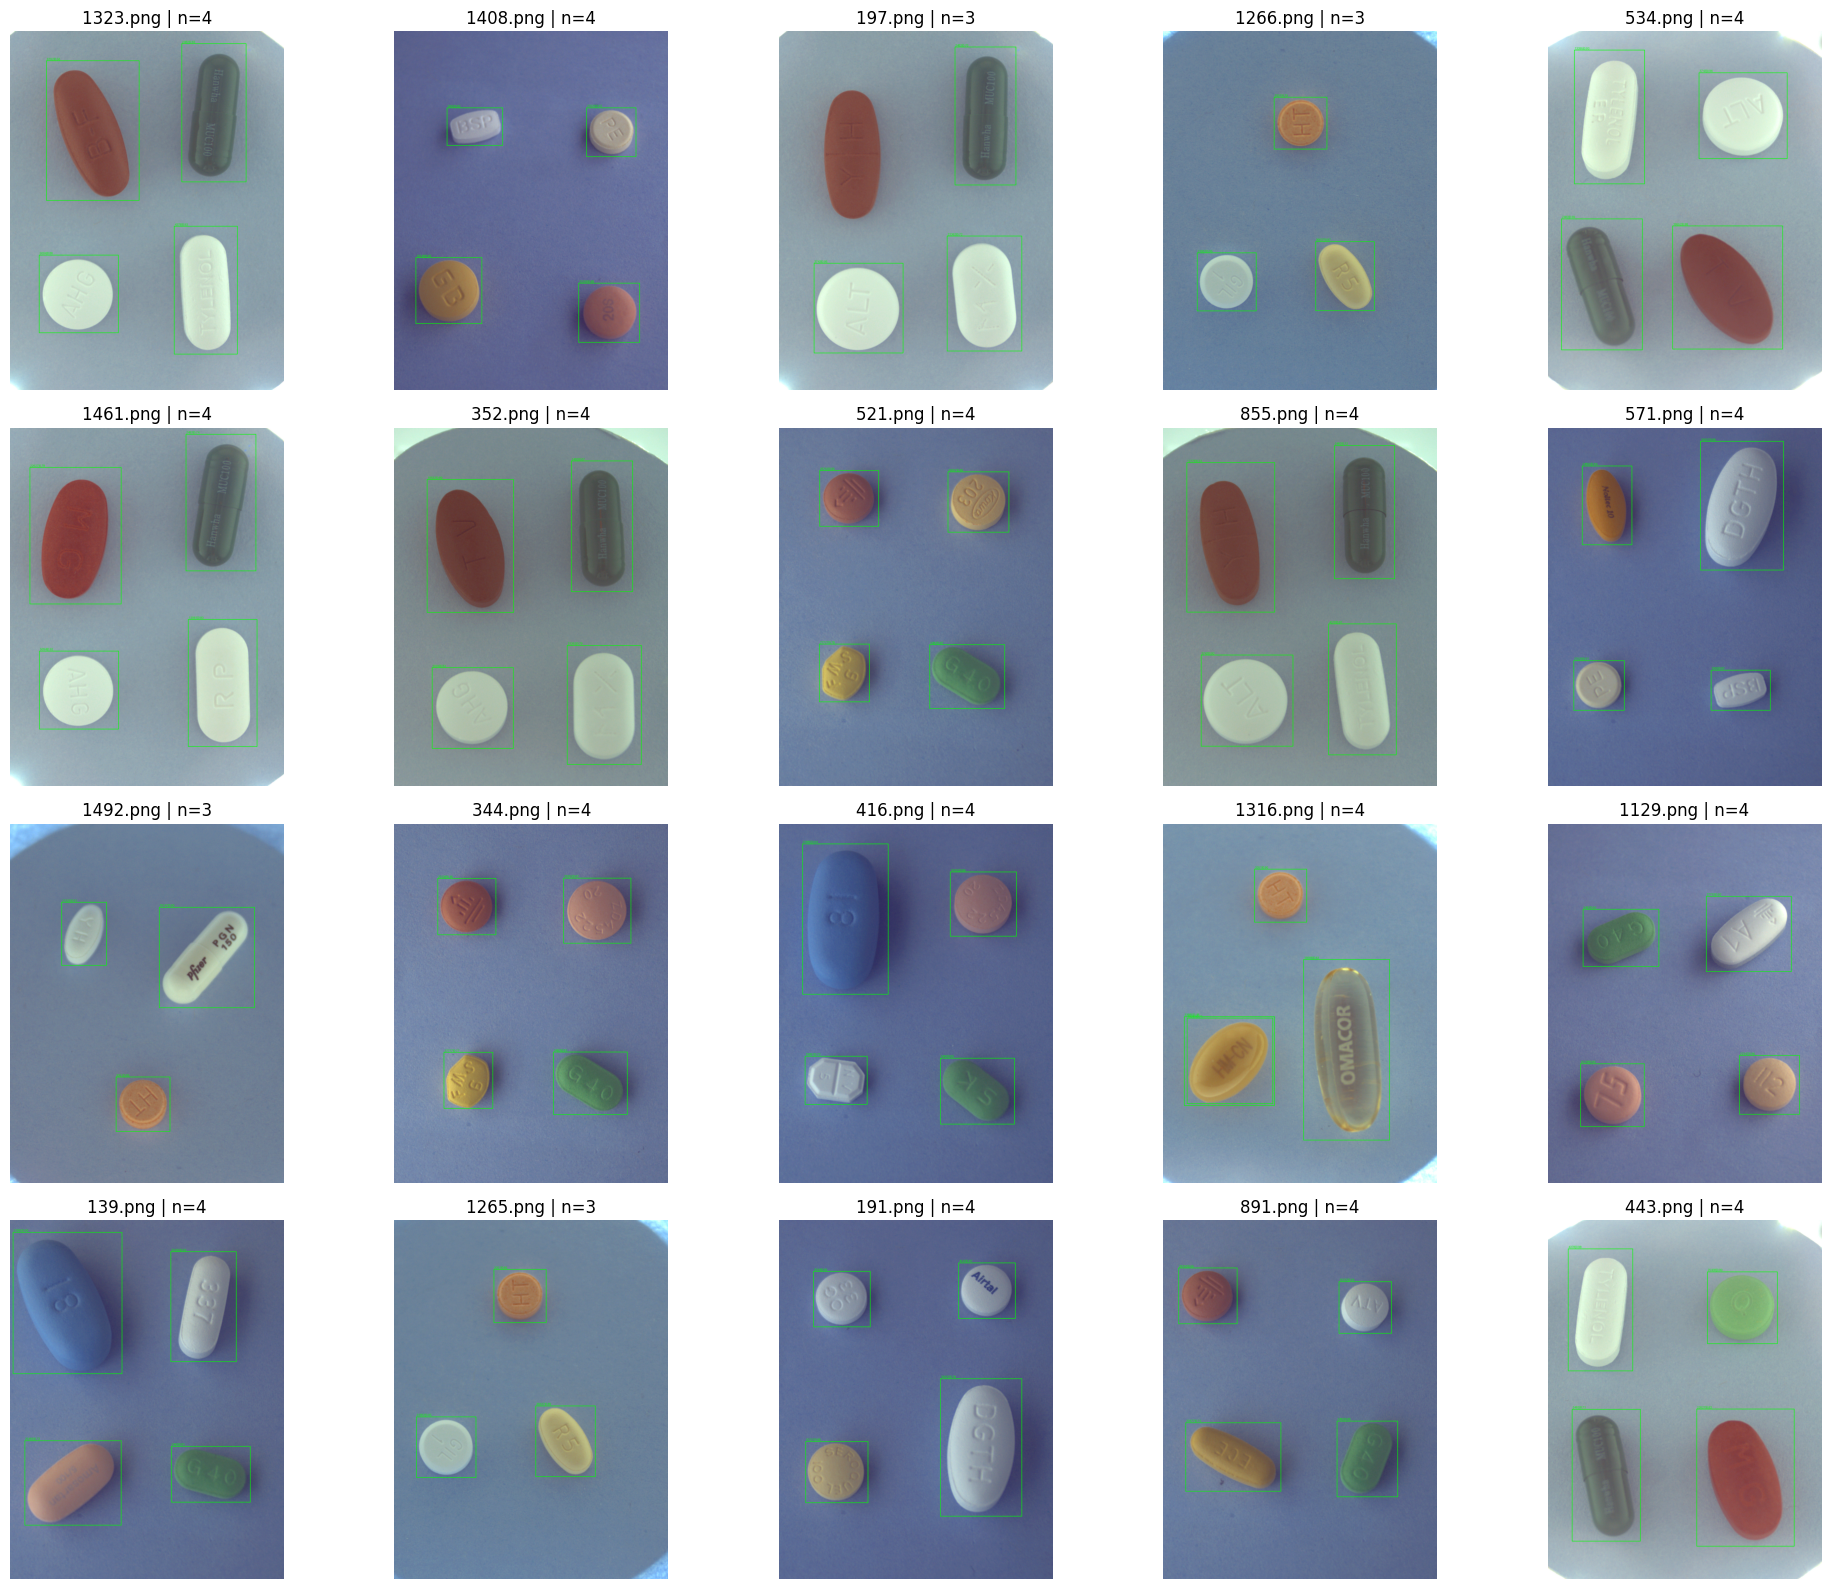

In [16]:
visualize_submission_csv(
    "/content/drive/MyDrive/data/초급_프로젝트/submission_ens_v8s_11m_augon.csv",
    "/content/drive/MyDrive/data/초급_프로젝트/dataset/final_test_images",
    n_images=20, cols=5, score_min=0.25
)

> 캐글 점수 : 0.96248 (하락함)